In [2]:
!pip install --upgrade gymnasium[atari,accept-rom-license]
!pip install --upgrade torch numpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.2/821.2 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 133.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import gymnasium as gym
import ale_py
from gymnasium.wrappers import FrameStackObservation

import numpy as np
import random
from collections import deque, namedtuple
import math
import time
import matplotlib.pyplot as plt

In [3]:
# --- Hyperparameters ---
# General
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

TOTAL_FRAMES = 1000000
BATCH_SIZE = 64
GAMMA = 0.99
TARGET_UPDATE_FREQUENCY = 1000 # C: Steps to update target network
REPLAY_BUFFER_SIZE = 100000
REPLAY_START_SIZE = 10000
LEARN_EVERY_N_STEPS = 4

# For Rainbow Agent
LEARNING_RATE_RAINBOW = 6.25e-5 # Adam learning rate
N_ATOMS = 51
V_MIN = -10.0
V_MAX = 10.0
ALPHA = 0.5
BETA = 0.4
N_STEPS = 3

# For Vanilla Agent
LEARNING_RATE_VANILLA = 1e-4
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 100000 # Adjusted for longer training

Using device: cuda


In [4]:
################################################################################
# COMPONENT 1: The Environment Setup
################################################################################

def make_env(env_id):
    """Creates and wraps the Atari environment for modern Gymnasium."""
    env = gym.make(env_id, render_mode=None)
    # AtariPreprocessing is a powerful wrapper that handles:
    # - Resizing screen to 84x84
    # - Grayscale conversion
    # - Applying a frame skip
    # - Stacking frames is handled separately by FrameStack
    env = gym.wrappers.AtariPreprocessing(env, screen_size=84, grayscale_obs=True, frame_skip=1, noop_max=30)
    env = FrameStackObservation(env, 4)
    return env

In [5]:
################################################################################
# COMPONENT 2: Replay Buffers (Standard vs. Prioritized N-Step)
################################################################################

# For Vanilla DQN: A standard experience replay buffer
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
        self.experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])

    def add(self, state, action, reward, next_state, done):
        e = self.experience(state, action, reward, next_state, done)
        self.buffer.append(e)

    def sample(self, batch_size):
        experiences = random.sample(self.buffer, k=batch_size)
        states, actions, rewards, next_states, dones = zip(*experiences)

        states = np.array(states)
        actions = np.array(actions)
        rewards = np.array(rewards)
        next_states = np.array(next_states)
        dones = np.array(dones)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

# For Rainbow DQN: A prioritized replay buffer with n-step logic
class SumTree:
    def __init__(self, capacity):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1)
        self.data = np.zeros(capacity, dtype=object)
        self.data_pointer = 0
        self.size = 0

    def _propagate(self, tree_index, change):
        parent = (tree_index - 1) // 2
        self.tree[parent] += change
        if parent != 0:
            self._propagate(parent, change)

    def _retrieve(self, tree_index, s):
        left_child = 2 * tree_index + 1
        right_child = left_child + 1
        if left_child >= len(self.tree):
            return tree_index
        if s <= self.tree[left_child]:
            return self._retrieve(left_child, s)
        else:
            return self._retrieve(right_child, s - self.tree[left_child])

    def total_priority(self):
        return self.tree[0]

    def add(self, priority, data):
        tree_index = self.data_pointer + self.capacity - 1
        self.data[self.data_pointer] = data
        self.update(tree_index, priority)
        self.data_pointer = (self.data_pointer + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def update(self, tree_index, priority):
        change = priority - self.tree[tree_index]
        self.tree[tree_index] = priority
        self._propagate(tree_index, change)

    def get(self, s):
        leaf_index = self._retrieve(0, s)
        data_index = leaf_index - self.capacity + 1
        return (leaf_index, self.tree[leaf_index], self.data[data_index])

class PrioritizedNStepReplayBuffer:
    def __init__(self, capacity, alpha, n_steps, gamma):
        self.tree = SumTree(capacity)
        self.alpha = alpha
        self.beta = BETA
        self.beta_increment_per_sampling = (1.0 - BETA) / TOTAL_FRAMES
        self.epsilon = 1e-5
        self.max_priority = 1.0

        self.n_steps_buffer = deque(maxlen=n_steps)
        self.n_steps = n_steps
        self.gamma = gamma

    def _get_n_step_info(self):
        reward, next_state, done = self.n_steps_buffer[-1][-3:]
        for _, _, r, ns, d in reversed(list(self.n_steps_buffer)[:-1]):
            reward = r + self.gamma * reward * (1 - d)
            next_state, done = (ns, d) if d else (next_state, done)
        return reward, next_state, done

    def add(self, state, action, reward, next_state, done):
        transition = (state, action, reward, next_state, done)
        self.n_steps_buffer.append(transition)
        if len(self.n_steps_buffer) < self.n_steps:
            return

        n_step_reward, final_next_state, final_done = self._get_n_step_info()
        start_state, start_action, _, _, _ = self.n_steps_buffer[0]

        n_step_experience = (start_state, start_action, n_step_reward, final_next_state, final_done)
        self.tree.add(self.max_priority, n_step_experience)

        if done:
            while len(self.n_steps_buffer) > 0:
                n_step_reward, final_next_state, final_done = self._get_n_step_info()
                start_state, start_action, _, _, _ = self.n_steps_buffer.popleft()
                n_step_experience = (start_state, start_action, n_step_reward, final_next_state, final_done)
                self.tree.add(self.max_priority, n_step_experience)

    def sample(self, batch_size):
        batch = []
        tree_indices = np.empty(batch_size, dtype=np.int32)
        priorities = np.empty(batch_size)
        segment = self.tree.total_priority() / batch_size

        self.beta = np.min([1., self.beta + self.beta_increment_per_sampling])

        for i in range(batch_size):
            a, b = segment * i, segment * (i + 1)
            s = random.uniform(a, b)
            (tree_idx, p, data) = self.tree.get(s)

            priorities[i] = p
            batch.append(data)
            tree_indices[i] = tree_idx

        sampling_probabilities = priorities / self.tree.total_priority()
        is_weights = np.power(self.tree.size * sampling_probabilities, -self.beta)
        is_weights /= is_weights.max()

        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones)), tree_indices, torch.from_numpy(is_weights)

    def update_priorities(self, tree_indices, priorities):
        priorities = (np.abs(priorities) + self.epsilon) ** self.alpha
        for idx, p in zip(tree_indices, priorities):
            self.tree.update(idx, p)
        self.max_priority = max(self.max_priority, priorities.max())

    def __len__(self):
        return self.tree.size

In [6]:
################################################################################
# COMPONENT 3: Network Architectures (Vanilla DQN vs. Rainbow)
################################################################################

class NoisyLinear(nn.Module):
    def __init__(self, in_features, out_features, std_init=0.5):
        super(NoisyLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.std_init = std_init
        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.empty(out_features, in_features))
        self.register_buffer('weight_epsilon', torch.empty(out_features, in_features))
        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_sigma = nn.Parameter(torch.empty(out_features))
        self.register_buffer('bias_epsilon', torch.empty(out_features))
        self.reset_parameters()
        self.sample_noise()

    def reset_parameters(self):
        mu_range = 1 / math.sqrt(self.in_features)
        self.weight_mu.data.uniform_(-mu_range, mu_range)
        self.weight_sigma.data.fill_(self.std_init / math.sqrt(self.in_features))
        self.bias_mu.data.uniform_(-mu_range, mu_range)
        self.bias_sigma.data.fill_(self.std_init / math.sqrt(self.out_features))

    def _scale_noise(self, size):
        return torch.randn(size, device=self.weight_mu.device).sign() * torch.randn(size, device=self.weight_mu.device).abs().sqrt()

    def sample_noise(self):
        epsilon_in = self._scale_noise(self.in_features)
        epsilon_out = self._scale_noise(self.out_features)
        self.weight_epsilon.copy_(epsilon_out.ger(epsilon_in))
        self.bias_epsilon.copy_(epsilon_out)

    def forward(self, x):
        if self.training:
            return F.linear(x, self.weight_mu + self.weight_sigma * self.weight_epsilon, self.bias_mu + self.bias_sigma * self.bias_epsilon)
        else:
            return F.linear(x, self.weight_mu, self.bias_mu)

class RainbowDQN(nn.Module):
    def __init__(self, input_shape, n_actions, n_atoms, v_min, v_max):
        super(RainbowDQN, self).__init__()
        self.n_actions = n_actions
        self.n_atoms = n_atoms
        self.register_buffer("atoms", torch.linspace(v_min, v_max, n_atoms))

        self.conv_layers = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1), nn.ReLU()
        )
        conv_out_size = self._get_conv_out(input_shape)

        self.value_stream = nn.Sequential(
            NoisyLinear(conv_out_size, 512), nn.ReLU(),
            NoisyLinear(512, self.n_atoms)
        )
        self.advantage_stream = nn.Sequential(
            NoisyLinear(conv_out_size, 512), nn.ReLU(),
            NoisyLinear(512, self.n_actions * self.n_atoms)
        )

    def _get_conv_out(self, shape):
        o = self.conv_layers(torch.zeros(1, *shape))
        return int(np.prod(o.size()))

    def forward(self, x):
        x = x.float() / 255.0
        features = self.conv_layers(x).view(x.size(0), -1)
        value_dist = self.value_stream(features).view(-1, 1, self.n_atoms)
        advantage_dist = self.advantage_stream(features).view(-1, self.n_actions, self.n_atoms)
        dist = value_dist + advantage_dist - advantage_dist.mean(dim=1, keepdim=True)
        return F.log_softmax(dist, dim=2)

    def sample_noise(self):
        for module in self.modules():
            if isinstance(module, NoisyLinear):
                module.sample_noise()

class VanillaDQN(nn.Module):
    def __init__(self, input_shape, n_actions):
        super(VanillaDQN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1), nn.ReLU()
        )
        conv_out_size = self._get_conv_out(input_shape)
        self.fc_layers = nn.Sequential(
            nn.Linear(conv_out_size, 512), nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def _get_conv_out(self, shape):
        o = self.conv_layers(torch.zeros(1, *shape))
        return int(np.prod(o.size()))

    def forward(self, x):
        x = x.float() / 255.0
        features = self.conv_layers(x).view(x.size(0), -1)
        return self.fc_layers(features)

In [7]:
################################################################################
# COMPONENT 4: Agent Implementations
################################################################################

class RainbowAgent:
    def __init__(self, env):
        self.env = env
        self.input_shape = env.observation_space.shape
        self.n_actions = env.action_space.n

        self.online_net = RainbowDQN(self.input_shape, self.n_actions, N_ATOMS, V_MIN, V_MAX).to(DEVICE)
        self.target_net = RainbowDQN(self.input_shape, self.n_actions, N_ATOMS, V_MIN, V_MAX).to(DEVICE)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=LEARNING_RATE_RAINBOW, eps=1.5e-4)
        self.memory = PrioritizedNStepReplayBuffer(REPLAY_BUFFER_SIZE, ALPHA, N_STEPS, GAMMA)
        self.atoms = self.online_net.atoms

    def select_action(self, state):
        with torch.no_grad():
            state = torch.from_numpy(np.array(state)).float().unsqueeze(0).to(DEVICE)
            log_dist = self.online_net(state)
            q_values = (torch.exp(log_dist) * self.atoms).sum(dim=2)
            return q_values.argmax().item()

    def learn(self):
        if len(self.memory) < REPLAY_START_SIZE:
            return

        (states, actions, rewards, next_states, dones), indices, weights = self.memory.sample(BATCH_SIZE)

        states = torch.from_numpy(states).float().to(DEVICE)
        actions = torch.from_numpy(actions).long().to(DEVICE)
        rewards = torch.from_numpy(rewards).float().to(DEVICE)
        next_states = torch.from_numpy(next_states).float().to(DEVICE)
        dones = torch.from_numpy(dones).float().to(DEVICE)
        weights = weights.to(DEVICE)

        log_p = self.online_net(states)
        log_p_a = log_p[range(BATCH_SIZE), actions]

        with torch.no_grad():
            log_p_next_target = self.target_net(next_states)
            p_next_target = torch.exp(log_p_next_target)

            log_p_next_online = self.online_net(next_states)
            q_next_online = (torch.exp(log_p_next_online) * self.atoms).sum(dim=2)
            best_actions = q_next_online.argmax(dim=1)

            p_next_best = p_next_target[range(BATCH_SIZE), best_actions]

            Tz = rewards.unsqueeze(1) + (1 - dones.unsqueeze(1)) * (GAMMA ** N_STEPS) * self.atoms.unsqueeze(0)
            Tz = Tz.clamp(min=V_MIN, max=V_MAX)

            b = (Tz - V_MIN) / ((V_MAX - V_MIN) / (N_ATOMS - 1))
            l, u = b.floor().long(), b.ceil().long()

            l[(u > 0) * (l == u)] -= 1
            u[(l < (N_ATOMS - 1)) * (l == u)] += 1

            m = torch.zeros_like(p_next_best)
            offset = torch.linspace(0, (BATCH_SIZE - 1) * N_ATOMS, BATCH_SIZE).long().unsqueeze(1).to(DEVICE)

            m.view(-1).index_add_(0, (l + offset).view(-1), (p_next_best * (u.float() - b)).view(-1))
            m.view(-1).index_add_(0, (u + offset).view(-1), (p_next_best * (b - l.float())).view(-1))

        loss = -(m * log_p_a).sum(dim=1)
        priorities = loss.detach().cpu().numpy()
        self.memory.update_priorities(indices, priorities)
        loss = (loss * weights).mean()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.online_net.sample_noise()
        self.target_net.sample_noise()

class VanillaAgent:
    def __init__(self, env):
        self.env = env
        self.input_shape = env.observation_space.shape
        self.n_actions = env.action_space.n

        self.online_net = VanillaDQN(self.input_shape, self.n_actions).to(DEVICE)
        self.target_net = VanillaDQN(self.input_shape, self.n_actions).to(DEVICE)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=LEARNING_RATE_VANILLA)
        self.memory = ReplayBuffer(REPLAY_BUFFER_SIZE)
        self.steps_done = 0

    def select_action(self, state):
        eps_threshold = EPSILON_END + (EPSILON_START - EPSILON_END) * math.exp(-1. * self.steps_done / EPSILON_DECAY)
        self.steps_done += 1

        if random.random() > eps_threshold:
            with torch.no_grad():
                state = torch.from_numpy(np.array(state)).float().unsqueeze(0).to(DEVICE)
                q_values = self.online_net(state)
                return q_values.argmax().item()
        else:
            return self.env.action_space.sample()

    def learn(self):
        if len(self.memory) < REPLAY_START_SIZE:
            return

        states, actions, rewards, next_states, dones = self.memory.sample(BATCH_SIZE)

        states = torch.from_numpy(states).float().to(DEVICE)
        actions = torch.from_numpy(actions).long().unsqueeze(1).to(DEVICE)
        rewards = torch.from_numpy(rewards).float().unsqueeze(1).to(DEVICE)
        next_states = torch.from_numpy(next_states).float().to(DEVICE)
        dones = torch.from_numpy(dones).float().unsqueeze(1).to(DEVICE)

        q_predicted = self.online_net(states).gather(1, actions)

        with torch.no_grad():
            q_next = self.target_net(next_states).max(1)[0].unsqueeze(1)
            q_target = rewards + (1 - dones) * GAMMA * q_next

        loss = F.mse_loss(q_predicted, q_target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

In [8]:
################################################################################
# COMPONENT 5: The Training Loop & Visualization
################################################################################

def train(agent, env, total_frames, agent_name):
    print(f"--- Starting Training for {agent_name} ---")
    start_time = time.time()

    all_rewards = []
    episode_rewards = []

    state, _ = env.reset()
    state = np.array(state)

    for frame_idx in range(1, total_frames + 1):
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        episode_rewards.append(reward)
        agent.memory.add(state, action, reward, next_state, done)

        state = np.array(next_state)

        if done:
            all_rewards.append(sum(episode_rewards))
            episode_rewards = []
            state, _ = env.reset()
            state = np.array(state)

        # MODIFIED: Learn only every N steps
        if frame_idx % LEARN_EVERY_N_STEPS == 0 and frame_idx > REPLAY_START_SIZE:
            agent.learn()

        if frame_idx % TARGET_UPDATE_FREQUENCY == 0 and frame_idx > REPLAY_START_SIZE:
            agent.target_net.load_state_dict(agent.online_net.state_dict())

        if frame_idx % 50000 == 0:
            avg_reward = np.mean(all_rewards[-100:]) if all_rewards else 0
            elapsed_time = time.time() - start_time
            print(f"[{agent_name}] Frame: {frame_idx}/{total_frames} | "
                  f"Avg Reward (Last 100): {avg_reward:.2f} | "
                  f"Time: {elapsed_time:.2f}s")

    print(f"--- Finished Training for {agent_name} ---")
    return all_rewards

def plot_results(results_vanilla, results_rainbow):
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 8))
    plt.title("Rainbow DQN vs. Vanilla DQN on Breakout", fontsize=18, fontweight='bold')

    def moving_average(data, window_size):
        if len(data) < window_size: return np.array([])
        return np.convolve(data, np.ones(window_size), 'valid') / window_size

    window = 100

    if results_vanilla:
        vanilla_smooth = moving_average(results_vanilla, window)
        plt.plot(range(len(vanilla_smooth)), vanilla_smooth, label=f"Vanilla DQN (Moving Avg, w={window})", color='royalblue', alpha=0.9)

    if results_rainbow:
        rainbow_smooth = moving_average(results_rainbow, window)
        plt.plot(range(len(rainbow_smooth)), rainbow_smooth, label=f"Rainbow DQN (Moving Avg, w={window})", color='darkorange', alpha=1.0, linewidth=2)

    plt.xlabel("Episodes", fontsize=14)
    plt.ylabel("Total Reward per Episode", fontsize=14)
    plt.legend(fontsize=12)
    plt.show()

Initializing Vanilla DQN...
--- Starting Training for Vanilla DQN ---
[Vanilla DQN] Frame: 50000/1000000 | Avg Reward (Last 100): 2.47 | Time: 130.73s
[Vanilla DQN] Frame: 100000/1000000 | Avg Reward (Last 100): 5.25 | Time: 291.51s
[Vanilla DQN] Frame: 150000/1000000 | Avg Reward (Last 100): 7.03 | Time: 460.22s
[Vanilla DQN] Frame: 200000/1000000 | Avg Reward (Last 100): 10.04 | Time: 632.48s
[Vanilla DQN] Frame: 250000/1000000 | Avg Reward (Last 100): 11.77 | Time: 808.76s
[Vanilla DQN] Frame: 300000/1000000 | Avg Reward (Last 100): 13.10 | Time: 986.75s
[Vanilla DQN] Frame: 350000/1000000 | Avg Reward (Last 100): 13.89 | Time: 1165.28s
[Vanilla DQN] Frame: 400000/1000000 | Avg Reward (Last 100): 13.46 | Time: 1344.27s
[Vanilla DQN] Frame: 450000/1000000 | Avg Reward (Last 100): 15.16 | Time: 1523.27s
[Vanilla DQN] Frame: 500000/1000000 | Avg Reward (Last 100): 14.70 | Time: 1702.59s
[Vanilla DQN] Frame: 550000/1000000 | Avg Reward (Last 100): 15.47 | Time: 1882.15s
[Vanilla DQN] Fr

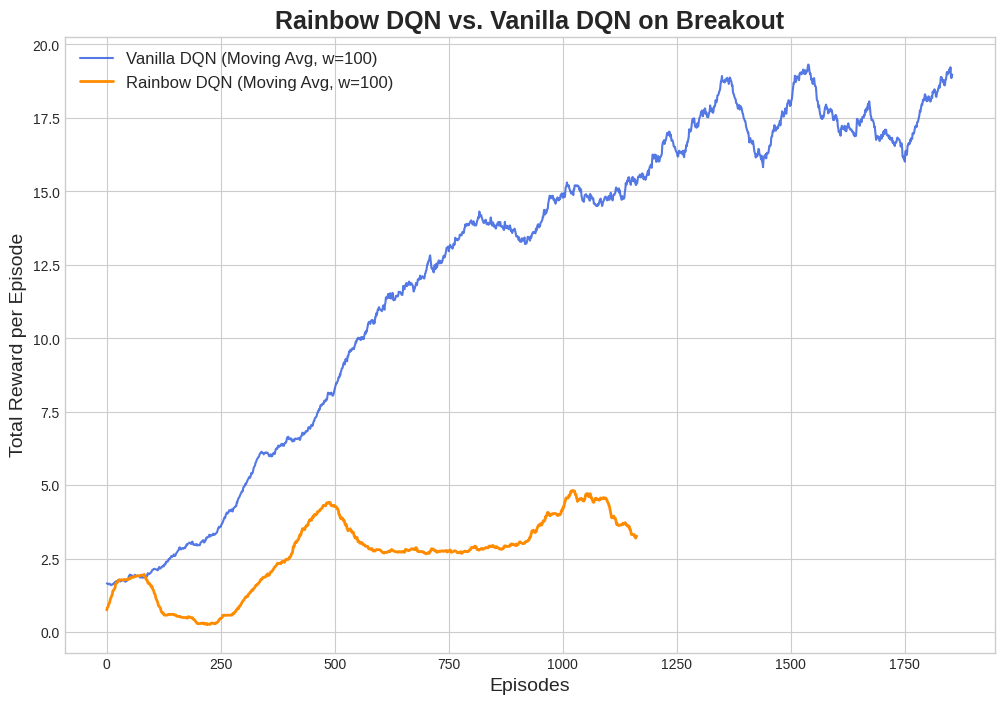

In [9]:
# --- Main Execution ---
if __name__ == "__main__":
    env_id = 'ALE/Breakout-v5'

    print("Initializing Vanilla DQN...")
    env_vanilla = make_env(env_id)
    agent_vanilla = VanillaAgent(env_vanilla)
    results_vanilla = train(agent_vanilla, env_vanilla, TOTAL_FRAMES, "Vanilla DQN")
    env_vanilla.close()

    print("\nInitializing Rainbow DQN...")
    env_rainbow = make_env(env_id)
    agent_rainbow = RainbowAgent(env_rainbow)
    results_rainbow = train(agent_rainbow, env_rainbow, TOTAL_FRAMES, "Rainbow DQN")
    env_rainbow.close()

    print("\n--- Plotting Results ---")
    plot_results(results_vanilla, results_rainbow)